#PIPELINE PER LA CLASSIFICAZIONE DEI TICKET IN CATEGORIE

# 1. Importazione delle librerie

In [1]:
import pandas as pd #serve per leggere e gestire i CSV
import re 

from sklearn.feature_extraction.text import TfidfVectorizer #Trasforma il testo in numeri
from sklearn.linear_model import LogisticRegression #Il modello che utilizzerò
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
    ) #serve per valuare il modello
import matplotlib.pyplot as plt #Serve per la matrice di confusione

# 2. Caricamento dei dataset e conversione in DataFrame Pandas

In [2]:
#Verifica del caricamento del dataset training
df_train = pd.read_csv('dataset_ticket_train.csv')
# Verifica del caricamento del dataset validation
df_valid = pd.read_csv('dataset_ticket_valid.csv')
# Verifica del caricamento del dataset test
df_test = pd.read_csv('dataset_ticket_test.csv')

# Verifica caricamento dataset
# Verifica training set
print('Train:', df_train.shape, df_train['category'].value_counts())
# Verifica validation set
print('Valid:', df_valid.shape, df_valid['category'].value_counts())
# Verifica test set
print('Test:', df_test.shape, df_test['category'].value_counts())

Train: (398, 5) category
Amministrazione    133
Tecnico            133
Commerciale        132
Name: count, dtype: int64
Valid: (50, 5) category
Commerciale        17
Amministrazione    17
Tecnico            16
Name: count, dtype: int64
Test: (50, 5) category
Tecnico            17
Commerciale        17
Amministrazione    16
Name: count, dtype: int64


# 3. Controllo delle colonne dei CSV

In [3]:
print ("Colonne presenti correttamente:")
print (df_train.columns.tolist())

print ("\nPrime righe del dataset di training:")
display(df_train.head())

Colonne presenti correttamente:
['id', 'title', 'body', 'category', 'priority']

Prime righe del dataset di training:


,id,title,body,category,priority
0,5xjl80ru,Pagamènto sèrvizio cloud in sospèso,Il bonifico rèlativo a l'accordo commèrcialè n...,Amministrazione,alta
1,o1h3iwuh,Disponibilità articolo gadgèt pèrsonalizzati,Avrèi bisogno di sapèrè sè possiamo rèpèrirè 2...,Commerciale,bassa
2,hu313e26,Comportamènto anomalo durantè importazionè ordini,Durantè la gèstionè di alcuni articoli dèstina...,Tecnico,alta
3,indtmw3g,Richièsta rimborso pèr anno contabilè,La somma corrisposta dovrèbbè èssèrè rèstituit...,Amministrazione,media
4,ljd3v663,Richièsta rimborso pèr fornitura matèriali,La somma corrisposta dovrèbbè èssèrè rèstituit...,Amministrazione,media


# 4. Controllo distribuzione corretta delle categorie

In [4]:
print ("Categoria nel Train:")
print (df_train["category"].value_counts())

print ("\nCategorie nel Valid:")
print (df_valid["category"].value_counts())

print ("\nCateogire nel test:")
print (df_test["category"].value_counts())

Categoria nel Train:
category
Amministrazione    133
Tecnico            133
Commerciale        132
Name: count, dtype: int64

Categorie nel Valid:
category
Commerciale        17
Amministrazione    17
Tecnico            16
Name: count, dtype: int64

Cateogire nel test:
category
Tecnico            17
Commerciale        17
Amministrazione    16
Name: count, dtype: int64


# 5. Preparazione del testo: titolo e descrizione in un'unica stringa

In [5]:
#Dataset del train
x_train = df_train["title"] + " " + df_train["body"]
y_train = df_train["category"]

#Dataset del valid
x_valid = df_valid ["title"] + " " + df_valid["body"]
y_valid = df_valid["category"]

#Dataset del test
x_test = df_test ["title"] + " " + df_test["body"]
y_test = df_test  ["category"]

# 6. Preprocessing del testo

In [6]:
#Pulizia di base del testo
def pulisci_testo(testo):
    testo = testo.lower()
    testo = re.sub(r"[^\w\s]"," ", testo)
    testo = re.sub(r"\s+", " ", testo)
    testo = testo.strip()
    return testo

x_train = x_train.apply(pulisci_testo)
x_valid = x_valid.apply(pulisci_testo)
x_test = x_test.apply(pulisci_testo)

print("Esempio di testo dopo il preprocessing")
print(x_train.iloc[0])


Esempio di testo dopo il preprocessing
pagamènto sèrvizio cloud in sospèso il bonifico rèlativo a l accordo commèrcialè non comparè ancora tra lè opèrazioni règistratè potètè vèrificarè


# 7. Creazione della pipeline TF-IDF e Logistic Regression categoria

In [7]:
# Creazione pipeline per classificazione delle categorie 
pipeline_categoria = Pipeline([
    ("tfidf",TfidfVectorizer( # trasformazione del testo in valori numerici
        lowercase = True,
        ngram_range = (1,2)
    )),
    ("logreg", LogisticRegression( # Creazione del modello di classificazione Logistic Regression
        max_iter = 1000
        ))
])

print ("Pipeline creata correttamente.")

Pipeline creata correttamente.


# 8. Addestramento del modello

In [8]:
# Ricerca dei migliori parametri per la categoria

# Provo alcune combinazioni semplici di parametri.
# Il parametro C controlla la regolarizzazione della Logistic Regression.
# ngram_range stabilisce se considerare singole parole o coppie di parole.
parametri = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "logreg__C": [0.01 , 0.1 , 1, 10]
}

grid_search_categoria = GridSearchCV(
    pipeline_categoria,
    parametri,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search_categoria.fit(x_train, y_train)

print("Migliori parametri per la categoria:")
print(grid_search_categoria.best_params_)
print("Miglior F1 macro ottenuto in cross-validation:", round(grid_search_categoria.best_score_, 4))

Migliori parametri per la categoria:
{'logreg__C': 0.01, 'tfidf__ngram_range': (1, 1)}
Miglior F1 macro ottenuto in cross-validation: 1.0


# 9. Predizioni validation test

In [9]:
# Previsione categorie validation
y_valid_pred = grid_search_categoria.predict(x_valid)

# Calcolo Accuracy del validation
accuracy_valid = accuracy_score(y_valid, y_valid_pred)

# Calcolo F1 macro del validation
f1_valid = f1_score(y_valid, y_valid_pred, average="macro")

print("Risultati VALIDATION")
print("Accuracy:", round(accuracy_valid, 4))
print("F1 macro:", round(f1_valid, 4))

print("Classification report - VALIDATION")
print(classification_report(y_valid, y_valid_pred))

Risultati VALIDATION
Accuracy: 1.0
F1 macro: 1.0
Classification report - VALIDATION
                 precision    recall  f1-score   support

Amministrazione       1.00      1.00      1.00        17
    Commerciale       1.00      1.00      1.00        17
        Tecnico       1.00      1.00      1.00        16

       accuracy                           1.00        50
      macro avg       1.00      1.00      1.00        50
   weighted avg       1.00      1.00      1.00        50



# 10. Valutazione finale su test set

In [10]:
# Previsione della categoria sul test
y_test_pred = grid_search_categoria.predict(x_test)

# Calcolo accuracy test
accuracy_test = accuracy_score(y_test, y_test_pred)

# Calcolo F1 macro test
f1_test = f1_score(y_test, y_test_pred, average="macro")

print("Risultati TEST")
print("Accuracy:", round(accuracy_test, 4))
print("F1 macro:", round(f1_test, 4))

print("Classification report - TEST")
print(classification_report(y_test, y_test_pred))

Risultati TEST
Accuracy: 1.0
F1 macro: 1.0
Classification report - TEST
                 precision    recall  f1-score   support

Amministrazione       1.00      1.00      1.00        16
    Commerciale       1.00      1.00      1.00        17
        Tecnico       1.00      1.00      1.00        17

       accuracy                           1.00        50
      macro avg       1.00      1.00      1.00        50
   weighted avg       1.00      1.00      1.00        50



# 11. Creazione matrice di confusione

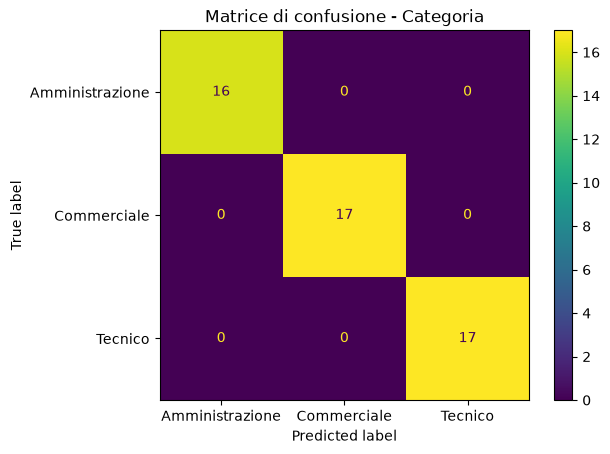

In [11]:
# Calcolo della matrice di confuzione 
cm_categoria = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_categoria,
    display_labels=grid_search_categoria.classes_
)

# Visualizzazione della matrice
disp.plot()
plt.title("Matrice di confusione - Categoria")
plt.show()

# 12. Controllo overfitting

In [12]:
# Previsione sul training test
y_train_pred = grid_search_categoria.predict(x_train)

# Calcolo accuracy del training
accuracy_train = accuracy_score(y_train, y_train_pred)

# Calcolo F1 macro sul training 
f1_train = f1_score(y_train, y_train_pred, average="macro")

print("Accuracy TRAIN:", round(accuracy_train, 4))
print("F1 macro TRAIN:", round(f1_train, 4))

print("\nAccuracy TEST:", round(accuracy_test, 4))
print("F1 macro TEST:", round(f1_test, 4))

print("\nDifferenza Accuracy train-test:",
      round(accuracy_train - accuracy_test, 4))

print("Differenza F1 train-test:",
      round(f1_train - f1_test, 4))

Accuracy TRAIN: 1.0
F1 macro TRAIN: 1.0

Accuracy TEST: 1.0
F1 macro TEST: 1.0

Differenza Accuracy train-test: 0.0
Differenza F1 train-test: 0.0


In [13]:
# Salvataggio del modello definitivo
import joblib

modello_categoria_definitivo = grid_search_categoria.best_estimator_

joblib.dump(
    modello_categoria_definitivo,
    "Logistic_Regression_definitiva_categorie.pkl"
)

print("Modello definitivo per la classificazione delle categorie salvato correttamente.")

Modello definitivo per la classificazione delle categorie salvato correttamente.
